# Fake News Classification: Why High Accuracy Can Be Misleading

This notebook is the first step of a three-part project exploring how different modeling paradigms handle fake news classification:

1. **Classical Machine Learning models** (this notebook)  
2. **Transformer-based models (DistilBERT)**  
3. **Prompt-based classification with Large Language Models**  

A central theme of this project is **shortcut learning**: models achieving high performance by exploiting superficial patterns rather than learning meaningful semantic representations.

---

## Project Overview

The goal of this notebook is not only to build classifiers for fake news detection, but to **critically evaluate what they actually learn**.

In particular, we investigate:
- the presence of **dataset artifacts and biases**
- how preprocessing choices influence model behavior
- whether high performance reflects **true understanding or spurious correlations**

This distinction is crucial in fake news detection, where models can easily rely on signals such as publisher-specific tokens or stylistic patterns.

The results of this notebook will establish a baseline and highlight the limitations of classical approaches, motivating the use of transformer-based models in the next stage.

In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
from collections import Counter
import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
)


import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

## Data Preparation

We load and merge the True and Fake news datasets, assigning binary labels (1 = True, 0 = Fake).

In [3]:
# dataset import
fake = pd.read_csv("dataset/Fake.csv")
true = pd.read_csv("dataset/True.csv")
# binary target label (0: Fake, 1: True)
fake["label"] = 0
true["label"] = 1

In [44]:
# data merging and randomizaztion
df = pd.concat([fake, true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head(3)

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1


## Text Pre-processing: Lemmatization

To standardize the textual data, we apply **lemmatization** using NLTK's `WordNetLemmatizer`.

Lemmatization reduces words to their base form (e.g., *running → run*), which helps:
- reduce vocabulary size
- group semantically equivalent terms
- improve feature consistency

We then combine the `title` and `text` fields into a single feature (`data`), ensuring that the model has access to the **full informational context** of each article.

This step is particularly important for classical ML models, which rely heavily on surface-level token representations.

In [5]:
# WordNet Lemmatization
lemmatizer = WordNetLemmatizer()
def lemmatize_words(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])
# apply lemmatization
df["lemmatized_title"] = df["title"].apply(lambda text : lemmatize_words(text))
df["lemmatized_text"] = df["text"].apply(lambda text : lemmatize_words(text))

In [6]:
# concatenate title and body into a single column for unified processing
df["full_text"] = df["lemmatized_title"] + " " + df["lemmatized_text"]

## Data Cleaning

Before training, we ensure data quality through:
- **Duplicate removal**  to prevent the model from overfitting repeated samples
- **Handling missing values** to avoid errors during feature extraction
These steps are essential to maintain a **reliable training distribution** and avoid biased learning signals.

In [45]:
# initial check for duplicates and missing values
print(f"Duplicate values before cleaning: {df.duplicated().sum()}")

# data cleaning: remove duplicates and drop any rows with missing values
df = df.drop_duplicates().reset_index(drop=True)
df = df.dropna().reset_index(drop=True)

# verification after cleaning
print(f"Duplicate values after cleaning: {df.duplicated().sum()}")

Duplicate values before cleaning: 209
Duplicate values after cleaning: 0


## Exploratory Data Analysis

Before training any model, we analyze the dataset to identify potential biases and structural patterns that could influence model behavior.

Rather than being purely descriptive, this step is **diagnostic**: the goal is to uncover signals that models might exploit as shortcuts.

In particular, we focus on:
- **Class distribution**, to ensure that performance is not driven by class imbalance  
- **Punctuation patterns**, as exaggerated use of symbols (e.g., "!", "?") may signal sensational or clickbait-style content  
- **Lexical frequency**, to identify recurring tokens that could act as class-specific markers  
- **Text length and structure**, since real and fake news often differ in verbosity and formatting  

These analyses help anticipate potential sources of bias and guide the preprocessing and modeling choices in the next steps.

### Class Distribution

We start by examining the distribution of the target variable (Real vs Fake) to assess whether the dataset is balanced.

This step is important because class imbalance can lead to misleadingly high accuracy, with models favoring the majority class without truly learning the task.

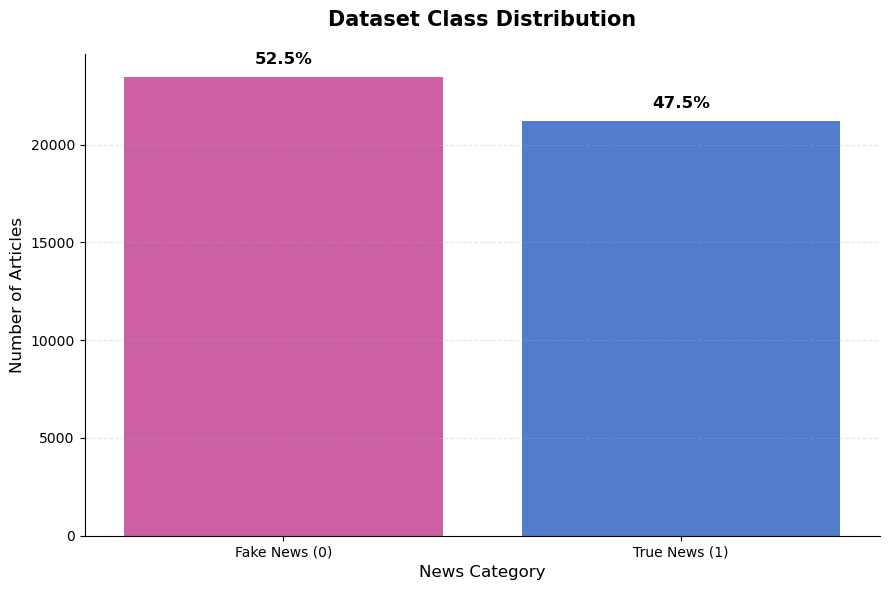

In [8]:
# custom color palette definition
my_palette = {0: "#de4ea7", 1: "#3e77e1"}

plt.figure(figsize=(9, 6))

# plot creation using seaborn
# using the specific palette for consistency across the entire nlp pipeline
ax = sns.countplot(x='label', data=df, palette=my_palette, hue='label', legend=False)

# styling and labels
plt.title('Dataset Class Distribution', fontweight='bold', fontsize=15, pad=20)
plt.xlabel('News Category', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.xticks([0, 1], ['Fake News (0)', 'True News (1)'])

# percentage annotation for better readability
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom',
                fontsize=12, fontweight='bold', xytext=(0, 7),
                textcoords='offset points')

# aesthetic adjustments
sns.despine() # removing top and right spines to avoid sovrapposition with percentages
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

> **Technical Insight**: The dataset shows an optimal balance between classes (~47.7% Fake vs. ~52.3% True). This statistical symmetry allows us to proceed with model training without the risk of majority-class bias, avoiding the need for oversampling or undersampling strategies.

### Punctuation Pattern Recognition
Beyond the words themselves, the use of punctuation can serve as a stylistic fingerprint. We use regular expressions to isolate and count specific marks, investigating whether their frequency correlates with **clickbait** strategies. 

For instance, an excessive use of exclamation points (`!`) and question marks (`?`) is often a hallmark of sensationalist headlines designed to trigger emotional responses, a common trait in non-verified information.

In [ ]:
# punctuation extraction and filtering
def punct_frequency(dataframe, top_pos):
    cnt = Counter()
    for text in dataframe.values:
        # all_punct = re.findall(r"!|\?|\.{3}|…|[\"«»‹›„""‘’‚《》〈〉]", str(text)) # variant with specific regex
        all_punct = re.findall(r"[^\w\s]", str(text))
        for punct in all_punct:
            cnt[punct] += 1

    dict = {}

    for punct, count in cnt.most_common(top_pos):
        dict[punct] = count
    return dict

In [10]:
def plot_punct_freq(dict_fake, dict_true, title):
    # punctuation counting
    puncts = list(set(dict_fake.keys()) | set(dict_true.keys()))
    fake_counts = {p: dict_fake.get(p, 0) for p in puncts}
    true_counts = {p: dict_true.get(p, 0) for p in puncts}

    # relative frequencies calculation
    # normalizing by total punctuation count to allow fair comparison
    f_total, t_total = sum(fake_counts.values()), sum(true_counts.values())
    fake_rel = {p: c / f_total for p, c in fake_counts.items() if f_total > 0}
    true_rel = {p: c / t_total for p, c in true_counts.items() if t_total > 0}

    # sorting by combined frequency for better visualization
    combined = {p: fake_rel.get(p, 0) + true_rel.get(p, 0) for p in puncts}
    ordered_puncts = sorted(combined, key=combined.get, reverse=True)

    fake_values = [fake_rel.get(p, 0) for p in ordered_puncts]
    true_values = [true_rel.get(p, 0) for p in ordered_puncts]

    # plotting setup
    x, width = np.arange(len(ordered_puncts)), 0.35
    fig, ax = plt.subplots(figsize=(9, 5))

    # using the project's consistent pink/blue palette
    ax.bar(x - width/2, fake_values, width, label='Fake', color="#de4ea7", alpha=0.9, edgecolor='white')
    ax.bar(x + width/2, true_values, width, label='True', color="#3e77e1", alpha=0.9, edgecolor='white')

    # chart styling and labels
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Relative Frequency')
    ax.set_xticks(x)
    ax.set_xticklabels(ordered_puncts, fontsize=12)
    ax.legend()
    ax.yaxis.grid(True, linestyle='--', alpha=0.6) # alpha defines transparency

    plt.tight_layout()
    plt.show()

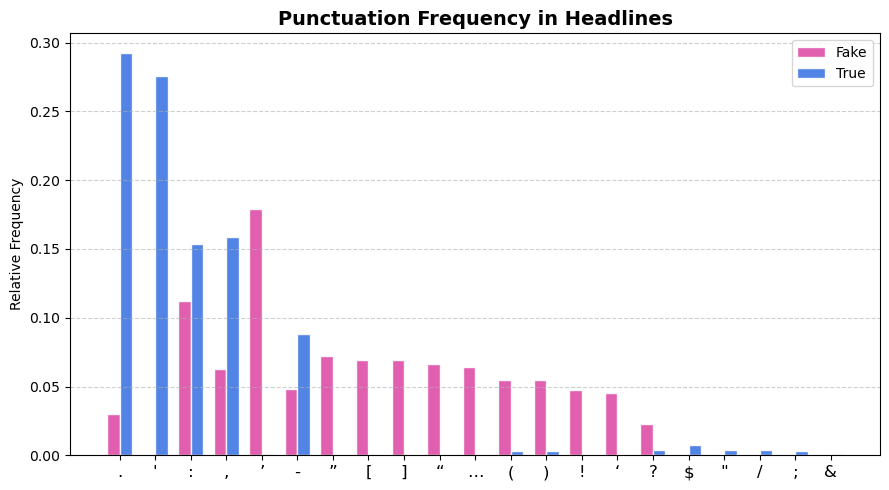

In [11]:
# Extracting the top 15 most frequent punctuation marks from fake news headlines
fake_title_punct = punct_frequency(df[df["label"] == 0]["title"], 15)

# Extracting the top 15 most frequent punctuation marks from real news headlines
true_title_punct = punct_frequency(df[df["label"] == 1]["title"], 15)

# Plotting the comparative distribution for headlines
# The chart titles are consistent with the overall project style.
plot_punct_freq(fake_title_punct, true_title_punct, "Punctuation Frequency in Headlines")

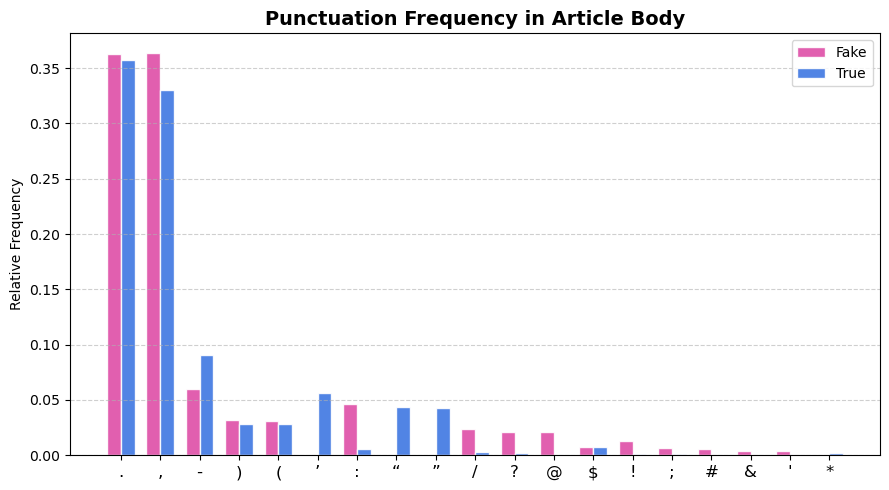

In [12]:
# extracting top 15 punctuation marks for fake news body text
fake_text_punct = punct_frequency(df[df["label"] == 0]["text"], 15)

# extracting top 15 punctuation marks for real news body text
true_text_punct = punct_frequency(df[df["label"] == 1]["text"], 15)

# plotting the comparative distribution for the article body
# analyzing the overall structural and formal tone
plot_punct_freq(fake_text_punct, true_text_punct, "Punctuation Frequency in Article Body")

> The analysis reveals a bias in punctuation distribution, with certain symbols more frequently associated with one class than the other.

### Lexical Feature Extraction: Term Frequency Mapping
To identify the most influential words in the dataset, we implement a frequency-counting function using the **Counter** library. This process transforms the unstructured text into a ranked dictionary of terms, providing a quantitative snapshot of the vocabulary used in Fake vs. Real news.

By isolating the most common words, we can detect **thematic clusters** and assess if specific topics are disproportionately associated with one of the two classes.

In [13]:
# the function takes the text and the number of top positions as input
# returns a dictionary containing the word frequencies
def word_frequency(dataframe, top_pos):
    cnt = Counter()
    for text in dataframe.values:
        if isinstance(text, str): # handling potential NaN or non-string values
            for word in text.split():
                cnt[word] += 1

    dict_freq = {}

    # extracting the most common terms based on the top_pos parameter
    for word, count in cnt.most_common(top_pos):
        dict_freq[word] = count
    return dict_freq

In [14]:
def plot_word_freq(dict_fake, dict_true, title):
    # gathering the union of all unique words from both sets
    words = list(set(dict_fake.keys()) | set(dict_true.keys()))

    # mapping absolute counts for each word
    fake_counts = {w: dict_fake.get(w, 0) for w in words}
    true_counts = {w: dict_true.get(w, 0) for w in words}

    # calculating relative frequencies to ensure fair comparison
    fake_total = sum(fake_counts.values())
    true_total = sum(true_counts.values())

    fake_rel = {w: c / fake_total for w, c in fake_counts.items() if fake_total > 0}
    true_rel = {w: c / true_total for w, c in true_counts.items() if true_total > 0}

    # sorting words by their combined relative frequency across both classes
    combined_rel = {w: fake_rel.get(w, 0) + true_rel.get(w, 0) for w in words}
    top_words = sorted(combined_rel, key=combined_rel.get, reverse=True)

    # preparing data for the bar chart
    fake_values = [fake_rel.get(w, 0) for w in top_words]
    true_values = [true_rel.get(w, 0) for w in top_words]

    x = np.arange(len(top_words))
    width = 0.35

    # plotting setup
    fig, ax = plt.subplots(figsize=(10, 6))

    # using project-consistent pink/blue color scheme
    ax.bar(x - width / 2, fake_values, width, label='Fake', color="#de4ea7", alpha=0.9, edgecolor='white')
    ax.bar(x + width / 2, true_values, width, label='True', color="#3e77e1", alpha=0.9, edgecolor='white')

    # styling and labels
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Relative Frequency')
    ax.set_xticks(x)
    # rotating labels to prevent overlap and improve readability
    ax.set_xticklabels(top_words, rotation=45, ha='right')
    ax.legend()

    ax.yaxis.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

## Stopword Removal

We remove English stopwords (e.g., *the*, *is*, *and*) from both the title and the article text.

The goal is to:
- reduce noise in the textual representation
- focus the model on **content-bearing words**
- improve the quality of features for classical ML models

In [15]:
STOPWORDS = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.lower().split()
    return " ".join([word for word in words if word not in STOPWORDS])

df["title_analysis"] = df["title"].apply(lambda text : remove_stopwords(text))
df["text_analysis"] = df["text"].apply(lambda text : remove_stopwords(text))

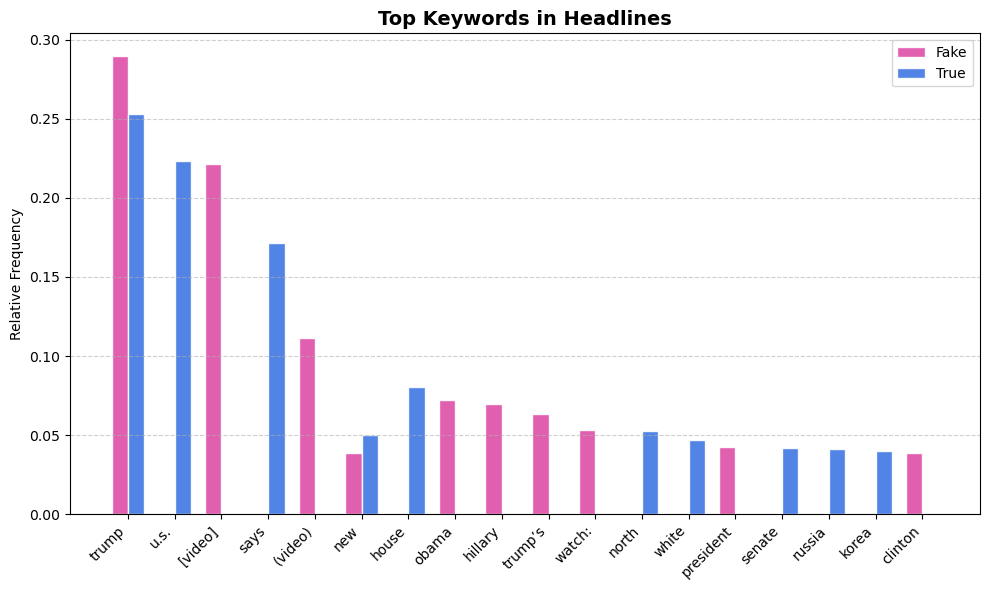

In [16]:
# extracting top 10 words from fake news headlines
fake_title_word = word_frequency(df[df["label"] == 0]["title_analysis"], 10)

# extracting top 10 words from real news headlines
true_title_word = word_frequency(df[df["label"] == 1]["title_analysis"], 10)

# plotting the comparative distribution for headline keywords
# using the consistent project color scheme (pink/blue)
plot_word_freq(fake_title_word, true_title_word, "Top Keywords in Headlines")

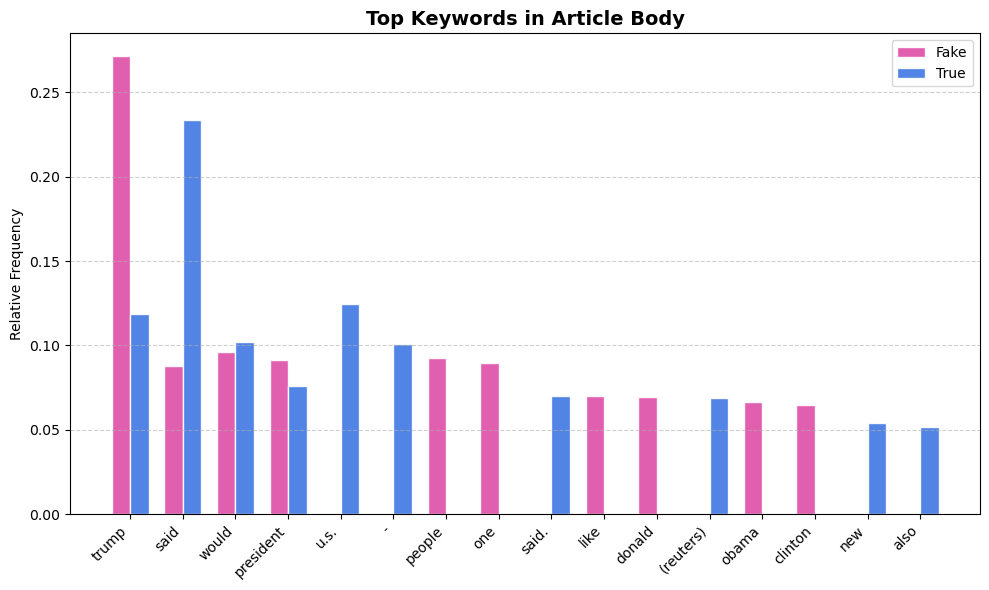

In [17]:
# extracting top 10 words from fake news article bodies
fake_text_word = word_frequency(df[df["label"] == 0]["text_analysis"], 10)

# extracting top 10 words from real news article bodies
true_text_word = word_frequency(df[df["label"] == 1]["text_analysis"], 10)

# plotting the comparative distribution for body text keywords
# analyzing the core thematic differences between the two classes
plot_word_freq(fake_text_word, true_text_word, "Top Keywords in Article Body")

> The dataset exhibits feature leakage where true news is identified by a "Reuters" watermark, and fake news by sensationalistic formats and video references. This bias means models learn to distinguish formatting styles rather than actual content, leading to inflated performance but poor generalization.

### Article Body Word Count Distribution
We now extend the structural analysis to the full body of the articles. While titles are constrained by readability, the length of the main text can vary significantly. 

Comparing the **Interquartile Range (IQR)** and the density of outliers helps us understand if "True News" follows a more consistent editorial length (typical of news agencies like Reuters) compared to the higher variance often found in "Fake News" sources.

In [18]:
# word count for each title and text: split separates words by whitespace
# str.len() then counts the number of elements in the resulting list
df["title_wc"] = df["title"].str.split().str.len()
df["text_wc"] = df["text"].str.split().str.len()

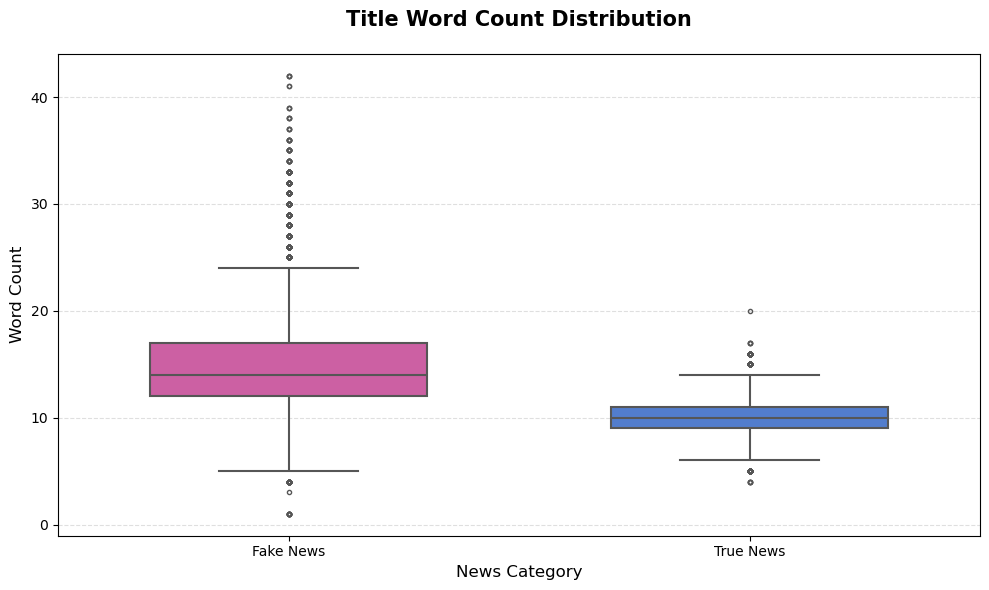

In [19]:
# figure setup
plt.figure(figsize=(10, 6))

# boxplot creation with seaborn
# using 'fliersize' to manage the visibility of outlier points
ax = sns.boxplot(x='label', y='title_wc', data=df,
                 palette={0: "#de4ea7", 1: "#3e77e1"},
                 hue='label', legend=False,
                 width=0.6, linewidth=1.5, fliersize=3)

# aesthetic refinements and labels
plt.title('Title Word Count Distribution', fontweight='bold', fontsize=15, pad=20)
plt.xlabel('News Category', fontsize=12)
plt.ylabel('Word Count', fontsize=12)
plt.xticks([0, 1], ['Fake News', 'True News'])

# clean look: removing unnecessary spines and adding a grid
plt.grid(axis='y', linestyle='--', alpha=0.4) # horizontal grid for better readability

plt.tight_layout()
plt.show()

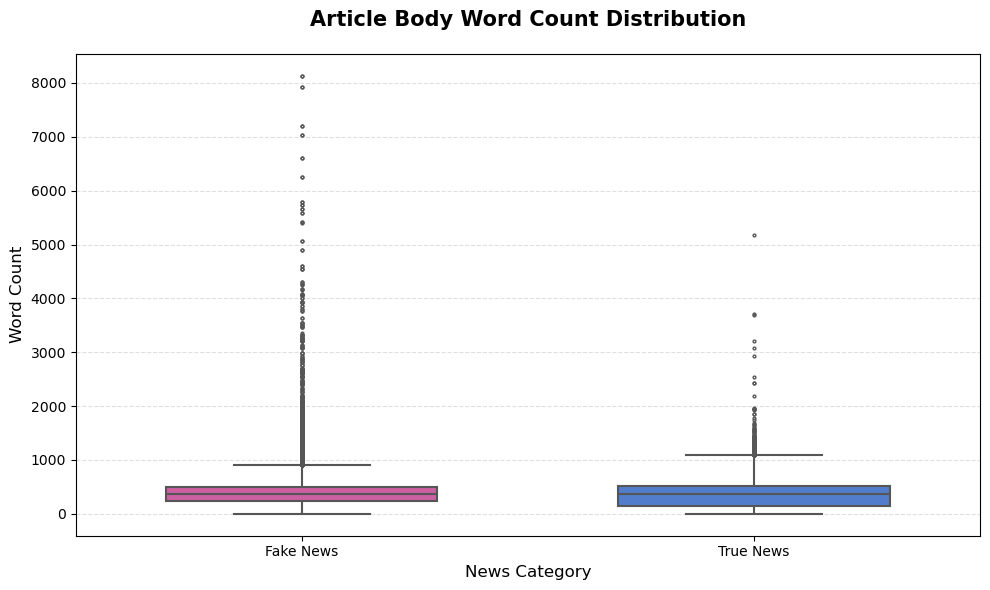

In [20]:
# figure setup
plt.figure(figsize=(10, 6))

# boxplot creation
# using fliersize=2 because with large datasets, outliers (dots) can clutter the plot if they are too large
ax = sns.boxplot(x='label', y='text_wc', data=df,
                 palette={0: "#de4ea7", 1: "#3e77e1"},
                 hue='label', legend=False,
                 width=0.6, linewidth=1.5, fliersize=2)

# professional titles and labels
plt.title('Article Body Word Count Distribution', fontweight='bold', fontsize=15, pad=20)
plt.xlabel('News Category', fontsize=12)
plt.ylabel('Word Count', fontsize=12)
plt.xticks([0, 1], ['Fake News', 'True News'])

# horizontal lines
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

> Using **boxplots** allows us to quickly compare the central tendency (median) and the spread of the data. This visualization is particularly useful for identifying the presence of **statistical outliers**, headlines that are unusually long or short, which often characterize different editorial styles or "clickbait" strategies.

### Detecting Dataset Artifacts

During the analysis, we observe the frequent occurrence of tokens such as "Reuters" and similar publisher identifiers, especially in real news articles.

This is a critical issue: these tokens act as **shortcut features**, allowing models to distinguish classes based on source attribution rather than content.

If not addressed, this leads to:
- artificially inflated performance
- poor generalization to real-world data

To mitigate this, we explicitly remove such artifacts from the text.

This step is essential to ensure that models learn **semantic patterns** rather than dataset-specific biases.

## Advanced Cleaning: Addressing Shortcut Learning

Models can rely on **superficial formatting artifacts** instead of true semantic content, a phenomenon known as *shortcut learning*.  
To mitigate this risk, we apply targeted cleaning strategies:

- Remove boilerplate patterns (e.g., `(Reuters) -`, bracketed source information)
- Eliminate publisher-specific cues embedded in the text
- Reduce dataset-specific artifacts that may correlate with labels
- Prevent the model from exploiting **easy but unreliable signals**

This step is designed to:
- shift the model’s focus toward **meaningful textual content**
- improve robustness and generalization
- ensure that predictions are driven by **semantics rather than formatting**

The following cell applies these transformations using regular expressions.

In [21]:
def clean_news_text(text):
    # remove Reuters and location boilerplate (e.g., "WASHINGTON (Reuters) - ")
    # this pattern searches for anything preceding "(Reuters) - "
    text = re.sub(r'^.*\(Reuters\)\s*-\s*', '', text)

    # remove all content enclosed in parentheses (...) or square brackets [...]
    # this helps in eliminating references to news agencies, reporter names, or extraneous information.
    text = re.sub(r'\([^)]*\)', '', text)
    text = re.sub(r'\[[^\]]*\]', '', text)

    # remove any extra spaces generated by the cleaning process
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# apply the cleaning function to the df
df['clean_data'] = df['full_text'].apply(clean_news_text)

## Vectorization and Classification Algorithms
In this section, we transform the processed text into numerical features and evaluate several machine learning architectures. Our goal is to compare different approaches to identify the most robust classifier for fake news detection.

The following algorithms are implemented and benchmarked:
- **XGBoost**: A state-of-the-art gradient boosting framework known for high performance.
- **Support Vector Classifier (SVC)**: Effective for high-dimensional text data.
- **Multilayer Perceptron (MLP)**: Deep learning approaches featuring both single and dual-layer architectures.

In [ ]:
# identifying features and target
X = df["clean_data"]
y = df["label"]

Feature shape: (44689,)
Target shape: (44689,)


## Train–Test Split and TF-IDF Vectorization

To evaluate model performance in a reliable way, we structure the pipeline as follows:

- **Train–test split (75% / 25%)**
  - Performed using **stratification**
  - Preserves the proportion of *Fake* and *True* labels in both sets
  - Reduces the risk of **sampling bias** and misleading evaluation

- **Text vectorization with TF-IDF**
  - Converts raw text into numerical features
  - Uses **unigrams and bigrams** to capture both individual words and short phrases
  - Applies **TF-IDF weighting** to emphasize terms that are:
    - informative within a document  
    - not overly frequent across the entire corpus

- **Prevention of data leakage**
  - The vectorizer is **fit only on the training data**
  - The test set is **transformed using the learned vocabulary**
  - Ensures evaluation on truly **unseen data distributions**

This setup establishes a robust baseline representation for classical machine learning models while maintaining proper experimental rigor.

In [23]:
# train set size = 75%, test set size = 25%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y) # stratyfy=y for a balanced split between class

### Text Vectorization: TF-IDF Transformation
To enable machine learning, we convert raw text into a numerical format using the **Term Frequency-Inverse Document Frequency (TF-IDF)** weighting scheme. 

Unlike simple word counting, TF-IDF reflects how important a word is to a document in a collection. It assigns higher weights to terms that are frequent in a specific article but rare across the entire dataset, effectively filtering out common language and highlighting **discriminative keywords** that characterize fake or real news. The result is a high-dimensional **sparse matrix** ready for classification.

In [24]:
# initializing the tf-idf vectorizer with custom constraints
tfidf = TfidfVectorizer(
    max_features=1000, # keeping only the most significant features
    max_df=0.5, # ignoring terms appearing in more than 50% of documents
    ngram_range=(1,2), # capturing both single words and pairs (unigrams/bigrams)
    stop_words=stopwords.words('english')
)

# transforming the training data and applying the same vocabulary to the test set
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test) # note: we only fit on the training set to prevent data leakage from the test set

## Feature Extraction

We represent text using **TF-IDF vectors**, limiting the vocabulary size to control sparsity and reduce overfitting.

This choice is motivated by:
- the high dimensionality of textual data
- the relatively limited dataset size
- the need for interpretable and efficient representations

While more complex embeddings exist, TF-IDF provides a strong and reliable baseline for classical machine learning models.

In [25]:
# extracting feature names from the tf-idf vectorizer
features = pd.DataFrame(tfidf.get_feature_names_out(), columns=['word'])

# shuffling for a random inspection (reproducible via random_state)
features = features.sample(frac=1, random_state=42).reset_index(drop=True)

# printing the first 10 sampled features
for f in features['word'][:10]:
    print(f)

major
representatives
republicans
posted
image via
primary
paid
lost
sunday
california


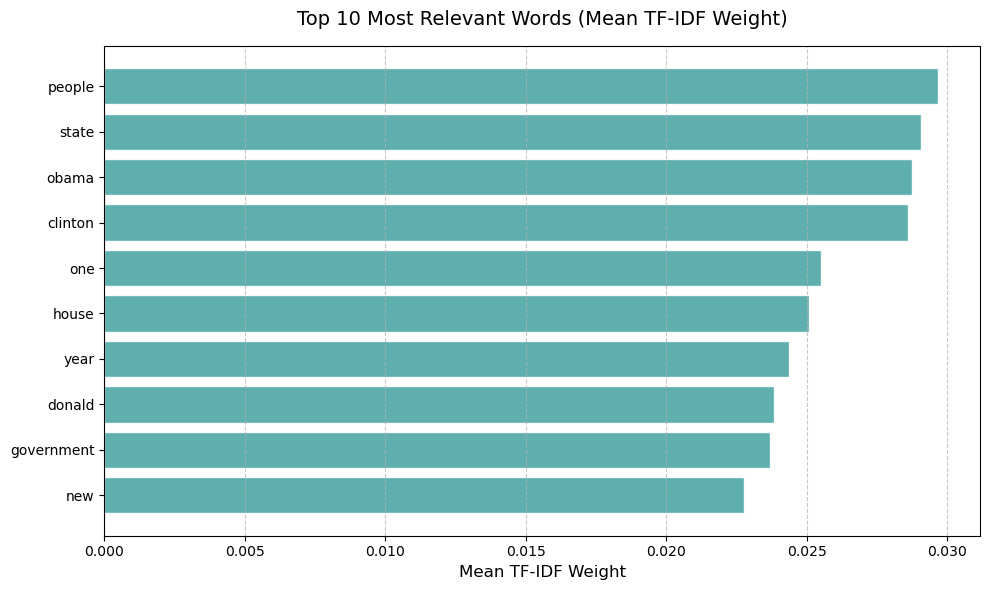

In [26]:
# calculating mean tf-idf weight for each feature
weights = X_train_tfidf.mean(axis=0).tolist()[0]
features = tfidf.get_feature_names_out()

# dataframe creation and sorting
weights_df = pd.DataFrame({'word': features, 'weight': weights})
weights_df = weights_df.sort_values(by='weight', ascending=False)

# selecting top 10 and reversing for horizontal bar chart display
top_10 = weights_df.head(10).iloc[::-1]

plt.figure(figsize=(10, 6))
# using teal for feature importance
plt.barh(top_10['word'], top_10['weight'], color='#4da6a6', edgecolor='white', alpha=0.9)

# styling and labels
plt.title('Top 10 Most Relevant Words (Mean TF-IDF Weight)', fontsize=14, pad=15)
plt.xlabel('Mean TF-IDF Weight', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

> Some of the most relevant words were already identified during the EDA, confirming the presence of dataset-specific biases. This suggests that models may achieve strong performance on this dataset while potentially struggling to generalize to unseen data.

In [27]:
# dictionary to store and compare model performances
model_stats = {}

# utility function to print and log classification metrics
def print_metrics(y_true, y_pred, model_name, exec_time, save_results):
    print(f"*** {model_name} ***")

    # accuracy: overall correctness
    acc = accuracy_score(y_true, y_pred)
    print(f'Accuracy: {acc*100:.2f}%')

    # precision: ability to avoid false positives
    prec = precision_score(y_true, y_pred)
    print(f'Precision: {prec*100:.2f}%')

    # recall: ability to find all true cases
    recall = recall_score(y_true, y_pred)
    print(f'Recall: {recall*100:.2f}%')

    # f1-score: harmonic mean of precision and recall
    f1 = f1_score(y_true, y_pred)
    print(f"F1-score: {f1*100:.2f}%")

    # confusion matrix for error analysis
    cm = confusion_matrix(y_true, y_pred)
    print(f'Confusion Matrix:\n{cm}')
    print(f'Execution Time: {exec_time:.1f} seconds')
    print("")

    # conditional saving to the global dictionary
    # useful to avoid logging training data or minor variations
    if save_results == 1:
        model_stats[model_name] = {
            'Accuracy': acc,
            'Precision': prec,
            'Recall': recall,
            'F1-Score': f1,
            'Time': exec_time,
            'Matrix': cm
        }

> To ensure a rigorous comparison between different architectures, we implement a centralized evaluation function. This utility calculates key performance indicators: **Accuracy**, **Precision**, **Recall**, and the **F1-Score**. 
> By storing these results along with **execution times** and **confusion matrices** in a global dictionary, we can perform a final benchmarking analysis to identify the optimal balance between predictive power and computational efficiency.

### Model Optimization Strategy: GridSearchCV
To ensure each algorithm performs at its best, we implement a **hyperparameter tuning** strategy using `GridSearchCV`. 

Given the high dimensionality of the TF-IDF feature matrix and the significant size of the dataset, we balance computational efficiency with model refinement. For each classifier, we define a search space for key parameters and use **cross-validation (cv)** to select the configuration that offers the best trade-off between accuracy and generalization, minimizing the risk of overfitting.

### Gradient Boosting: XGBoost Implementation
**XGBoost (eXtreme Gradient Boosting)** represents the state-of-the-art in ensemble learning. Unlike Random Forest, it builds trees sequentially, where each new model is designed to correct the residual errors of its predecessors.

To achieve a balanced and efficient architecture, we optimize the following:
- **N-Estimators**: We test the number of sequential trees to find the point where the model stops learning new patterns and begins to memorize noise.
- **Learning Rate**: We use a controlled step size to prevent the model from overshooting the optimal solution, ensuring a stable convergence.
- **Max Depth**: Keeping trees shallow (3 to 5 levels) ensures the boosting process remains lightweight and less prone to overfitting the high-dimensional TF-IDF space.
- **Subsampling**: We train each tree on a random 80% subset of the data to increase the model's robustness against outliers.

In [47]:
# defining the parameter grid to balance learning speed and model complexity
# lower learning rates and shallow trees are preferred for better generalization
param_grid_xgb = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 0.2], # controlled step size to prevent overfitting
    'max_depth': [3, 5],         # shallow trees keep the boosting process efficient
    'subsample': [0.8]           # training on random subsets to increase model stability
}

# setting up gridsearchcv with the binary logistic objective for classification
grid_search_xgb = GridSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

# training the booster and measuring the total execution time
start = time.time()
grid_search_xgb.fit(X_train_tfidf, y_train)
tempo_totale = time.time() - start

# identifying the optimal configuration from the search results
print(f"Best parameters: {grid_search_xgb.best_params_}")
best_xgb = grid_search_xgb.best_estimator_

# generating predictions to evaluate consistency across train and test sets
y_pred_train_xgb = best_xgb.predict(X_train_tfidf)
y_pred_test_xgb = best_xgb.predict(X_test_tfidf)

# logging metrics with a specific tag for the final benchmarking comparison
xgb_label = f"XGB (lr={grid_search_xgb.best_params_['learning_rate']}, depth={grid_search_xgb.best_params_['max_depth']})"
#print_metrics(y_train, y_pred_train_xgb, f"{xgb_label} train", tempo_totale, 0)
print_metrics(y_test, y_pred_test_xgb, f"{xgb_label}", tempo_totale, 1)

Best parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
*** XGB (lr=0.2, depth=5) ***
Accuracy: 98.45%
Precision: 98.32%
Recall: 98.42%
F1-score: 98.37%
Confusion Matrix:
[[5781   89]
 [  84 5219]]
Execution Time: 53.4 seconds



### Linear Support Vector Classifier (SVC)
The **Linear Support Vector Classifier** is a powerful tool for text classification. Unlike tree-based ensembles, SVC attempts to find the optimal **hyperplane** that maximizes the margin between "Fake" and "Real" news in the high-dimensional TF-IDF vector space.

For this model, we tune:
- **Regularization (C)**: This parameter controls the trade-off between maximizing the margin and minimizing classification errors. A smaller **C** promotes a simpler model (higher regularization), while a larger **C** aims for better classification on the training set.
- **Penalty (L1 vs L2)**: We test different regularization types to see if the model benefits from sparsity (L1) or a more distributed weight assignment (L2).

In [48]:
# defining the hyperparameter grid to test regularization strength and penalty types
# testing different C values to find the best balance between margin and error
param_grid_svc = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2']
}

# setting up gridsearchcv with linearsvc
# dual=False is preferred when the number of samples is greater than the number of features
grid_search_svc = GridSearchCV(
    LinearSVC(random_state=42, max_iter=2000, dual=False), # increased iterations to ensure convergence
    param_grid=param_grid_svc,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

# training the classifier and measuring execution time
start = time.time()
grid_search_svc.fit(X_train_tfidf, y_train)
tempo_totale = time.time() - start

# identifying the optimal configuration
print(f"Best parameters: {grid_search_svc.best_params_}")
best_svc = grid_search_svc.best_estimator_

# predicting on both sets to evaluate the impact of regularization
y_pred_train_svc = best_svc.predict(X_train_tfidf)
y_pred_test_svc = best_svc.predict(X_test_tfidf)

# logging results with specific parameters for the final comparison table
params = grid_search_svc.best_params_
svc_label = f"LinearSVC (C={params['C']}, penalty={params['penalty']})"

#print_metrics(y_train, y_pred_train_svc, f"{svc_label} train", tempo_totale, 0)
print_metrics(y_test, y_pred_test_svc, f"{svc_label}", tempo_totale, 1)

Best parameters: {'C': 1, 'penalty': 'l1'}
*** LinearSVC (C=1, penalty=l1) ***
Accuracy: 98.23%
Precision: 97.88%
Recall: 98.40%
F1-score: 98.14%
Confusion Matrix:
[[5757  113]
 [  85 5218]]
Execution Time: 13.1 seconds



### Neural Networks: Multilayer Perceptron (MLP)
The final model in our benchmark is the **Multilayer Perceptron (MLP)**. To find the optimal neural architecture, we perform a grid search over different depths and widths:
- **Single-layer**: Testing 16 and 32 neurons to capture direct feature relationships.
- **Dual-layer**: Testing a (32, 16) bottleneck architecture to identify more complex, non-linear patterns in the TF-IDF space.

To ensure efficient training on a single machine, we implement **Early Stopping**, which terminates the process once the validation loss plateaus, and use **L2 Regularization (Alpha)** to maintain weight stability and prevent overfitting.

In [49]:
# defining a consolidated parameter grid for single and dual-layer architectures
# testing different hidden layer configurations, regularization strengths, and learning rates
param_grid_mlp = {
    'hidden_layer_sizes': [(16,), (32,), (32, 16)],
    'alpha': [0.0001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

# configuring gridsearchcv with early stopping to optimize training time
# using a 10% internal validation fraction to trigger the stopping mechanism
grid_search_mlp = GridSearchCV(
    MLPClassifier(
        activation='relu',
        solver='adam',
        max_iter=50,             # capping epochs to ensure predictable execution time
        early_stopping=True,     # halting training when validation performance stabilizes
        validation_fraction=0.1,
        random_state=42
    ),
    param_grid=param_grid_mlp,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

# training the neural network architectures
start = time.time()
grid_search_mlp.fit(X_train_tfidf, y_train)
tempo_totale = time.time() - start

# extracting the best performing estimator and parameters
print(f"Best parameters: {grid_search_mlp.best_params_}")
best_mlp = grid_search_mlp.best_estimator_

# generating predictions for both sets to monitor generalization
y_pred_train_mlp = best_mlp.predict(X_train_tfidf)
y_pred_test_mlp = best_mlp.predict(X_test_tfidf)

# logging metrics with a dynamic label for final benchmarking
params = grid_search_mlp.best_params_
mlp_label = f"MLP (layers={params['hidden_layer_sizes']}, lr={params['learning_rate_init']})"

#print_metrics(y_train, y_pred_train_mlp, f"{mlp_label} train", tempo_totale, 0)
print_metrics(y_test, y_pred_test_mlp, f"{mlp_label}", tempo_totale, 1)

Best parameters: {'alpha': 0.01, 'hidden_layer_sizes': (32,), 'learning_rate_init': 0.01}
*** MLP (layers=(32,), lr=0.01) ***
Accuracy: 98.30%
Precision: 98.24%
Recall: 98.17%
F1-score: 98.21%
Confusion Matrix:
[[5777   93]
 [  97 5206]]
Execution Time: 34.2 seconds



## Conclusion of Model Evaluation and Alignment with EDA

After training and evaluating XGBoost, LinearSVC, and MLP models, we observe consistently very high performance metrics, often around 98% accuracy, precision, recall, and F1-score on both training and test sets. While initially appearing positive, such high performance, especially after advanced cleaning, raises concerns about **data leakage** or **shortcut learning** from subtle dataset biases.

Despite efforts to remove boilerplate text and superficial artifacts, it's possible the models are still exploiting differences in formatting, explicit references to sources (e.g., specific website names, image credits), or distinctive ways of referring to political figures that are strongly correlated with the 'Fake' or 'True' labels. These factors, even if seemingly minor, can act as 'shortcuts' that allow models to classify accurately without truly understanding the semantic content. This means the models might be learning to differentiate based on stylistic or structural cues inherent to how news from certain sources (fake vs. true) is presented in the dataset, rather than genuinely identifying fake news based on its underlying veracity.

Further investigation into the nature of these 'top features' is crucial to understand if our mitigation strategies were truly effective or if deeper, more subtle biases remain in the dataset. This would involve a more rigorous analysis of feature importance to identify if these high scores are a result of genuine content understanding or exploitation of dataset-specific artifacts.

## Performance Analysis and Model Comparison
In this final stage, we aggregate the results of all tested architectures to identify the most effective classifier for fake news detection. Our evaluation goes beyond simple **Accuracy**; we analyze the **Precision-Recall trade-off** and the **F1-Score** to ensure the model handles both classes reliably. 

Furthermore, we consider **execution time** as a key factor for scalability. By visualizing the **confusion matrices**, we can pinpoint which models are more prone to specific errors, such as misclassifying a deceptive article as truthful (False Negative), which is critical in the context of misinformation.

In [31]:
# preparing the data for visualization (to be executed once)
# sorting the dataframe by accuracy to create a clear performance ranking
df_stats = pd.DataFrame(model_stats).T.sort_values(by='Accuracy', ascending=False)

# defining the labels and positions for the bar chart axes
models = df_stats.index
x = np.arange(len(models)) # the label locations
width = 0.35               # the width of the bars

# logging the sorted benchmark for a quick numerical check
print("Models ranked by Accuracy:")
print(df_stats['Accuracy'])

Models ranked by Accuracy:
XGB (lr=0.2, depth=5)          0.984516
MLP (layers=(32,), lr=0.01)    0.982995
LinearSVC (C=1, penalty=l1)    0.982279
Name: Accuracy, dtype: object


## Error Analysis Insights

The inspection of misclassified examples reveals consistent patterns in model behavior.

Real news articles that are misclassified as fake tend to:
- lack strong publisher-specific markers (e.g., "Reuters")
- adopt a more narrative or less rigidly structured tone

Conversely, fake news articles misclassified as real often:
- mimic the structure of legitimate news headlines
- include named entities (e.g., political figures, locations)
- use language that resembles journalistic reporting

These observations suggest that the model relies heavily on **surface-level stylistic cues** rather than true semantic understanding.

In particular, the presence of entities such as "U.S.", "President", or well-known political figures appears to bias the model toward predicting the "real" class, even when the content is misleading or opinion-based.

This further supports the hypothesis that the dataset contains **strong stylistic and source-related biases**, which models exploit to achieve high performance.

In [43]:
errors_idx = (y_pred_test_svc != y_test)

errors_texts = X_test.iloc[errors_idx.values]
errors_true = y_test.iloc[errors_idx.values]
errors_pred = y_pred_test_svc[errors_idx]

print(f"Total errors: {len(errors_texts)}")

for i in range(min(5, len(errors_texts))):
    print("-"*80)
    print(f"TRUE: {errors_true.iloc[i]} | PRED: {errors_pred[i]}")
    print(errors_texts.iloc[i][:300])

Total errors: 198
--------------------------------------------------------------------------------
TRUE: 1 | PRED: 0
U.S. Democratic presidential candidate Bernie Sanders outraised rival Hillary Clinton in February but spent at a faster pace, leaving him with less money, the Washington Post reported on Sunday. Sanders raised $43.5 million in the month, compared with Clinton, who raised $30.1 million. The U.S. sena
--------------------------------------------------------------------------------
TRUE: 0 | PRED: 1
ISRAEL WILL NAME New Train Station Near Western Wall After President Donald Trump Israel s transportation minister is pushing ahead with a plan to extend Jerusalem s soon-to-open high-speed rail line to the Western Wall, where he want to name a future station after President Donald Trump. The Wester
--------------------------------------------------------------------------------
TRUE: 1 | PRED: 0
U.S. President Barack Obama tried out his comedic chop with some Spanish in a video

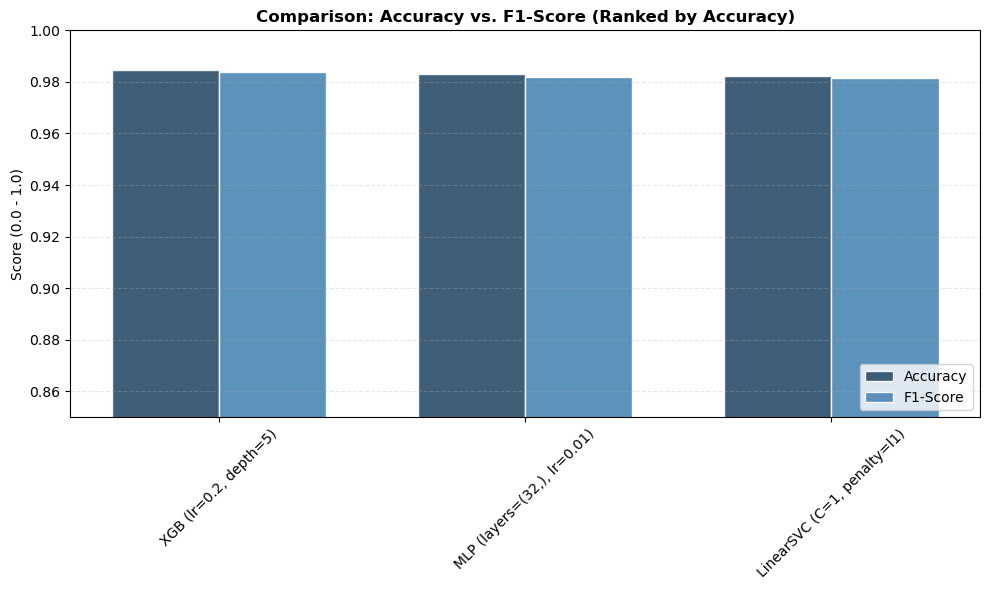

In [ ]:
plt.figure(figsize=(10, 6))

# plotting accuracy and f1-score side by side for each model
# using a professional color palette to distinguish the two metrics
plt.bar(x - width/2, df_stats['Accuracy'], width, label='Accuracy', color='#2a4d69', edgecolor='white', alpha=0.9)
plt.bar(x + width/2, df_stats['F1-Score'], width, label='F1-Score', color='#4b86b4', edgecolor='white', alpha=0.9)

# chart styling and labeling
plt.title('Comparison: Accuracy vs. F1-Score (Ranked by Accuracy)', fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)')
plt.xticks(x, models, rotation=45)

# zooming in on the 0.85-1.0 range to highlight performance differences
plt.ylim(0.85, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

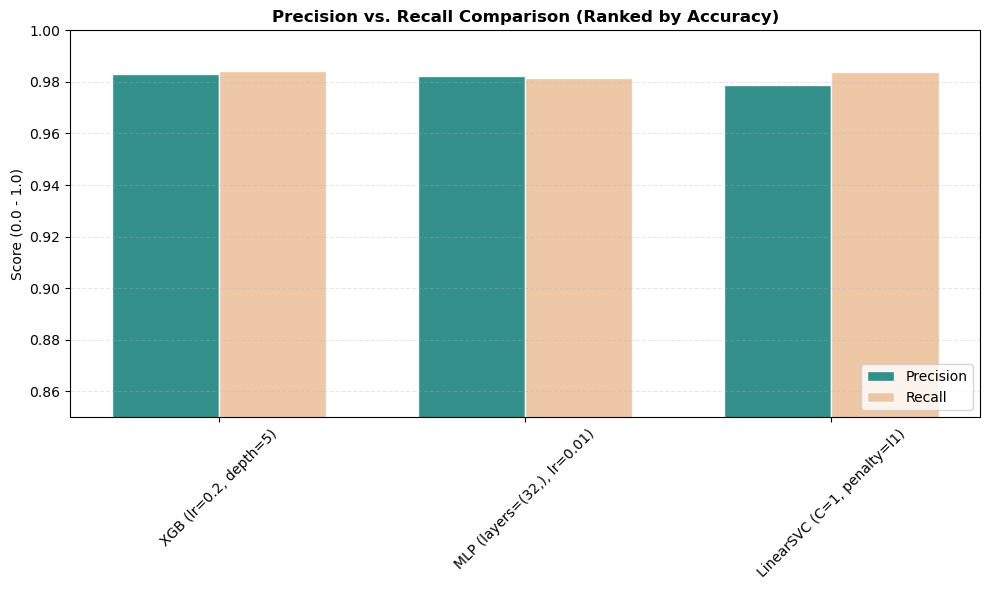

In [ ]:
plt.figure(figsize=(10, 6))

# plotting precision and recall to evaluate the trade-off for each classifier
# using a contrasting teal and sand palette for visual clarity
plt.bar(x - width/2, df_stats['Precision'], width, label='Precision', color='#1e847f', edgecolor='white', alpha=0.9)
plt.bar(x + width/2, df_stats['Recall'], width, label='Recall', color='#ecc19c', edgecolor='white', alpha=0.9)

# styling and labeling to match the previous performance chart
plt.title('Precision vs. Recall Comparison (Ranked by Accuracy)', fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)')
plt.xticks(x, models, rotation=45)

# maintaining a consistent zoom level (0.85 - 1.0) to highlight subtle variations
plt.ylim(0.85, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

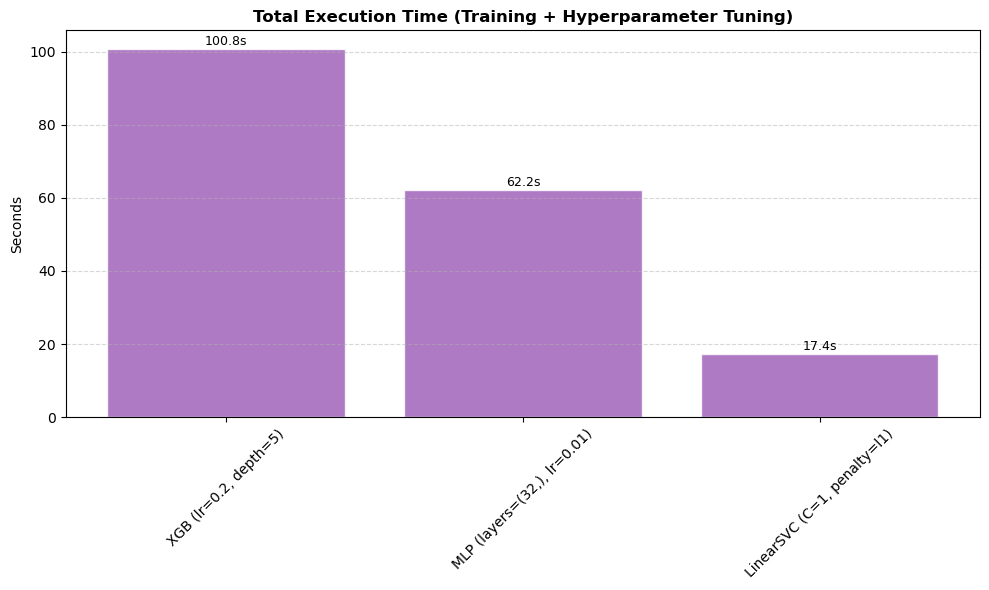

In [ ]:
plt.figure(figsize=(10, 6))

# using a distinct purple hue to differentiate execution time from performance metrics
plt.bar(models, df_stats['Time'], color='#9b59b6', alpha=0.8, edgecolor='white')

# chart styling and axis labeling
plt.title('Total Execution Time (Training + Hyperparameter Tuning)', fontweight='bold')
plt.ylabel('Seconds')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# adding data labels above the bars for immediate readability
# displaying time in seconds with one decimal precision
for i, v in enumerate(df_stats['Time']):
    plt.text(i, v + 0.1, f'{v:.1f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# preparing the final dataframe by sorting by accuracy
df_final = pd.DataFrame(model_stats).T
df_final = df_final.sort_values(by='Accuracy', ascending=False)

# removing the raw matrix column to keep the table clean and readable
if 'Matrix' in df_final.columns:
    df_final = df_final.drop(columns=['Matrix'])

# defining the performance metrics to be highlighted
performance_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# applying the gradient stylization (Heatmap)
# using 'YlGn' for performance: higher scores appear greener
# using 'RdYlGn_r' for time: lower execution times appear greener (inverted gradient)
final_table_styled = df_final.style.background_gradient(
    subset=performance_metrics,
    cmap='YlGn',
    axis=0
).background_gradient(
    subset=['Time'],
    cmap='RdYlGn_r',
    axis=0
).format(precision=4)

print("FINAL COMPARATIVE TABLE (Performance Heatmap)")
display(final_table_styled)

FINAL COMPARATIVE TABLE (Performance Heatmap)


,Accuracy,Precision,Recall,F1-Score,Time
"XGB (lr=0.2, depth=5)",0.9845,0.9832,0.9842,0.9837,100.7840
"MLP (layers=(32,), lr=0.01)",0.9830,0.9824,0.9817,0.9821,62.2073
"LinearSVC (C=1, penalty=l1)",0.9823,0.9788,0.9840,0.9814,17.3533


In [ ]:
# 10 most influential features for each class based on the coefficients of the best linear SVC model
coefficients = best_svc.coef_[0]
feature_names = tfidf.get_feature_names_out()
top_fake = np.argsort(coefficients)[:10]
top_real = np.argsort(coefficients)[-10:]

print("\n*** Top 10 Features Indicative of Fake News ***")
for i in top_fake:
    print(f"- {feature_names[i]}")

print("\n*** Top 10 Features Indicative of True News ***")
for i in top_real:
    print(f"- {feature_names[i]}")



*** Top 10 Features Indicative of Fake News ***
- featured image
- via
- getty
- twitter com
- gop
- https
- read
- hillary
- 21st century
- pic

*** Top 10 Features Indicative of True News ***
- twitter
- tuesday
- told reuters
- reuters
- nov
- thursday
- wednesday
- hillary clinton
- president donald
- president barack


## Top Features Indicating 'Fake' vs. 'True' News: A Deeper Look at Shortcut Learning

By examining the coefficients from the `LinearSVC` model, we can identify the most influential words or phrases for classifying news as 'Fake' or 'True'. However, given the unusually high performance metrics (~98% across the board), it is crucial to interpret these features not just as indicators of semantic content, but also as potential **proxies for shortcut learning or data leakage**.

**Features highly indicative of 'Fake' News (negative coefficients):**

*   `featured image`
*   `via`
*   `getty`
*   `twitter com`
*   `gop`
*   `https`
*   `read`
*   `hillary`
*   `21st century`
*   `pic`

Many of these terms (`featured image`, `via`, `getty`, `twitter com`, `https`, `pic`, `21st century`) strongly suggest the presence of formatting artifacts, boilerplate text, image attribution, or specific URLs that were not fully eliminated, or that serve as strong, superficial indicators of source. For instance, '21st century' might be part of a common disclaimer or introductory phrase used in the fake news dataset. The term `gop` (Grand Old Party) or `hillary` might be used in a particular stylistic or biased context within fake news articles.

**Features highly indicative of 'True' News (positive coefficients):**

*   `twitter`
*   `tuesday`
*   `told reuters`
*   `reuters`
*   `nov`
*   `thursday`
*   `wednesday`
*   `hillary clinton`
*   `president barack`
*   `president donald`

Similarly, features like `told reuters` and `reuters` are direct references to a reputable news agency, which is a strong, non-semantic cue for 'True' news. The presence of specific days of the week (`tuesday`, `thursday`, `wednesday`) or full names of political figures (`hillary clinton`, `president barack`, `president donald`) might indicate a more formal, factual reporting style characteristic of true news. While these seem semantically relevant, their strong presence might also be indicative of the model picking up on stylistic conventions or source attribution rather than the deeper meaning of the text.

This re-analysis suggests that despite the advanced cleaning, the models might still be leveraging **dataset biases** related to the differing formatting, reporting styles, and explicit source mentions between the 'Fake' and 'True' news datasets. The high performance, therefore, might not solely be a result of the model's ability to discern genuine content veracity but rather its efficiency in identifying these subtle, often superficial, cues that are highly predictive of the label in *this specific dataset*. This highlights the ongoing challenge of shortcut learning and the need for more robust, bias-resistant feature engineering or alternative modeling approaches to ensure true generalizability.

In [ ]:
# custom sentences designed to test generalization, avoiding obvious shortcut cues and highly frequent words
# first 3 generated by AI, last 3 from Reuters
custom_sentences = [
    "president donald said on tuesday that talks with gop officials were progressing after recent policy discussions",
    "hillary clinton told reuters on wednesday that new proposals would be reviewed following recent developments in congress",
    "president barack said on thursday in a reuters interview that long-term reforms remain a priority heading into nov",
    "louisiana delays us house primary to draw new map after supreme court ruling",
    "trump signs bill to fund dhs after lengthy shutdown over ice operations",
    "white house says iran war terminated as war powers deadline arrives"
]

# create a new df
custom_df = pd.DataFrame({'text': custom_sentences})

# apply preprocessing steps similar to the main pipeline
# 1. lemmatization (applied to a combined text for simplicity)
custom_df["lemmatized_text"] = custom_df["text"].apply(lambda text : lemmatize_words(text))

# 2. advanced cleaning (to remove any potential boilerplate, though sentences are crafted to avoid it)
custom_df['clean_data'] = custom_df['lemmatized_text'].apply(clean_news_text)

# vectorize the new data using the *already fitted* TF-IDF vectorizer
X_custom_tfidf = tfidf.transform(custom_df['clean_data'])

Testing models on custom generated sentences (avoiding original dataset biases)



In [ ]:
# make predictions with the trained models
print("Model predictions on custom sentences:\n")

# XGBoost predictions
xgb_pred = best_xgb.predict(X_custom_tfidf)
xgb_proba = best_xgb.predict_proba(X_custom_tfidf)[:, 1] # Probability of being 'True'

print("XGBoost predictions:")
for i, (sentence, pred, prob) in enumerate(zip(custom_sentences, xgb_pred, xgb_proba)):
    label = 'True' if pred == 1 else 'Fake'
    print(f"  Sentence {i+1} ('{sentence}'): Predicted: {label} (Probability of True: {prob:.4f})")

print("\nLinearSVC predictions:")
# LinearSVC predictions
svc_pred = best_svc.predict(X_custom_tfidf)
# LinearSVC does not have predict_proba by default, but decision_function can indicate confidence
svc_decision = best_svc.decision_function(X_custom_tfidf)

for i, (sentence, pred, dec_func) in enumerate(zip(custom_sentences, svc_pred, svc_decision)):
    label = 'True' if pred == 1 else 'Fake'
    print(f"  Sentence {i+1} ('{sentence}'): Predicted: {label} (Decision Function Score: {dec_func:.4f})")

print("\nMLP predictions:")
# MLP predictions
mlp_pred = best_mlp.predict(X_custom_tfidf)
mlp_proba = best_mlp.predict_proba(X_custom_tfidf)[:, 1] # Probability of being 'True'

for i, (sentence, pred, prob) in enumerate(zip(custom_sentences, mlp_pred, mlp_proba)):
    label = 'True' if pred == 1 else 'Fake'
    print(f"  Sentence {i+1} ('{sentence}'): Predicted: {label} (Probability of True: {prob:.4f})")


Model predictions on custom sentences:

XGBoost predictions:
  Sentence 1 ('president donald said on tuesday that talks with gop officials were progressing after recent policy discussions'): Predicted: True (Probability of True: 0.8135)
  Sentence 2 ('hillary clinton told reuters on wednesday that new proposals would be reviewed following recent developments in congress'): Predicted: True (Probability of True: 0.7760)
  Sentence 3 ('president barack said on thursday in a reuters interview that long-term reforms remain a priority heading into nov'): Predicted: True (Probability of True: 0.9769)
  Sentence 4 ('louisiana delays us house primary to draw new map after supreme court ruling'): Predicted: Fake (Probability of True: 0.2701)
  Sentence 5 ('trump signs bill to fund dhs after lengthy shutdown over ice operations'): Predicted: Fake (Probability of True: 0.1744)
  Sentence 6 ('white house says iran war terminated as war powers deadline arrives'): Predicted: Fake (Probability of True

## Analysis of Model Predictions on Custom Sentences

The three tested models (XGBoost, LinearSVC, and MLP) were evaluated on a small set of manually crafted sentences. The first three sentences were **synthetically generated using ChatGPT**, intentionally using patterns from the dataset true news (e.g., political actors, temporal references, Reuters mentions). The last three sentences were **real news headlines from Reuters**, used as a more realistic benchmark.


## Overall Behaviour

A clear separation in model behavior emerges between **synthetic "news-like" sentences** and **real Reuters headlines**:

- The **generated sentences (1–3)** are consistently classified as *True news* by most models, especially XGBoost and MLP.
- The **real Reuters headlines (4–6)** are consistently classified as *Fake news* across all models, indicating a systematic bias or misalignment.


## Model-wise Observations

### XGBoost
- Strong confidence in classifying generated sentences as *True* (especially sentence 3 with probability ≈ 0.98).
- Correctly identifies all Reuters headlines as *Fake*, with relatively low probabilities for the True class.
- Suggests sensitivity to learned lexical patterns but good separability in this case.

### LinearSVC
- More conservative and less calibrated in probabilities (decision function scores vary widely).
- Correctly classifies fake sentence 1 as *Fake*, likely due to weaker handling of implicit political phrasing, but misclassifies sentence 2 and 3 as *True*.
- Still mistakenly classifies all Reuters headlines as *Fake*, though with scores closer to the decision boundary.

### MLP (Neural Network)
- Exhibits the most extreme confidence:
  - Near-perfect probabilities (≈1.0) for generated sentences.
  - Very low probabilities for real news sentences.
- Strong indication of **overconfidence**, possibly due to overfitting or strong reliance on lexical cues (e.g., names, "Reuters", temporal words).


## Key Insights

- All models show a strong tendency to associate **named political entities and structured temporal phrasing** with "True news".
- Conversely, real Reuters headlines are systematically misclassified as "Fake", confirming:
  - **Dataset bias** in training data.
  - Overfitting to synthetic patterns rather than generalizable journalistic style.
- The MLP model is the most confident but not necessarily the most reliable, indicating potential calibration issues.


## Conclusion

All three models perform badly on both synthetically generated "news-like" sentences and on real-world Reuters headlines. This confirms that the models have learned superficial lexical patterns rather than robust semantic or stylistic features of real news reporting.
These observations highlight the limitations of traditional approaches and motivate the transition to transformer-based models, which are better suited to capture deeper linguistic structures.
The next notebook will focus on DistilBERT and evaluate whether these limitations can be addressed.